# Notas de Estadística: Métodos de Remuestreo (Jackknife y Bootstrap)

**Objetivo general:** profundizar en la teoría del remuestreo, derivar estimadores de sesgo y varianza, construir intervalos de confianza y aplicar estas ideas a datos astronómicos reales con Python.

**Temas principales:**
- Fundamentos del remuestreo y el principio plug‑in.
- Jackknife: sesgo, varianza y pseudovalores.
- Bootstrap: distribución muestral empírica, intervalos de confianza y BCa.
- Aplicaciones extensas con datos de exoplanetas.



## 1. Motivación: ¿por qué remuestrear?

En estadística aplicada (y especialmente en astronomía), casi nunca conocemos la distribución poblacional exacta. Cuando estimamos un parámetro $\theta$ mediante un estadístico $\hat{\theta} = f(X_1, \ldots, X_n)$, necesitamos cuantificar:

- **Sesgo:** $\operatorname{bias}(\hat{\theta}) = E[\hat{\theta}] - \theta$.
- **Varianza:** $\operatorname{Var}(\hat{\theta})$.
- **Distribución muestral:** necesaria para intervalos de confianza y pruebas de hipótesis.

El **remuestreo** reemplaza el muestreo repetido de la población (imposible en la práctica) por un muestreo repetido de la *muestra observada*, tratando a la distribución empírica como una aproximación razonable de la población.



## 2. Distribución empírica y principio plug‑in

Sea la **distribución empírica**:

\[
\widehat{F}_n(x) = \frac{1}{n} \sum_{i=1}^n \mathbf{1}\{X_i \le x\}
\]

El **principio plug‑in** sugiere estimar cantidades funcionales de $F$ reemplazando $F$ por $\widehat{F}_n$.

Ejemplos:
- $\theta = E[X] \Rightarrow \hat{\theta} = \bar{X}$.
- $\theta = \operatorname{Var}(X) \Rightarrow \hat{\theta} = s^2$.

El bootstrap consiste en generar nuevas muestras $X^*$ de $\widehat{F}_n$ y estudiar la variabilidad de $\hat{\theta}^* = f(X^*)$.



## 3. Jackknife: teoría ampliada

### 3.1 Definición y estimadores

Para cada $i=1,\ldots,n$ se elimina un dato y se recalcula el estimador:

\[
\hat{\theta}_{(i)} = f(X_1, \ldots, X_{i-1}, X_{i+1}, \ldots, X_n)
\]

El promedio Jackknife es
\[
\bar{\theta}_{(\cdot)} = \frac{1}{n}\sum_{i=1}^n \hat{\theta}_{(i)}
\]

El **estimador Jackknife corregido** para el sesgo:
\[
\hat{\theta}_{\text{Jack}} = n\hat{\theta} - (n-1)\bar{\theta}_{(\cdot)}
\]

### 3.2 Varianza Jackknife
\[
\widehat{\operatorname{Var}}_{\text{Jack}}(\hat{\theta}) = \frac{n-1}{n}\sum_{i=1}^n (\hat{\theta}_{(i)} - \bar{\theta}_{(\cdot)})^2
\]

### 3.3 Pseudovalores e influencia

Se definen los **pseudovalores**
\[
\theta_i^{(\text{pseudo})} = n\hat{\theta} - (n-1)\hat{\theta}_{(i)}
\]

Si un punto tiene alta influencia, su pseudovalor se separa del resto. Esto conecta el Jackknife con el concepto de **función de influencia**, muy útil para diagnósticos en astronomía (detección de objetos atípicos).

### 3.4 Limitaciones
- Funciona mejor para **estimadores suaves**.
- Puede fallar con estimadores no diferenciables (medianas, cuantiles extremos).
- En muestras pequeñas, el Jackknife puede sobreestimar la varianza.



## 4. Bootstrap: teoría ampliada

### 4.1 Algoritmo básico

1. Tomar $B$ muestras bootstrap $X^{*(b)}$ de tamaño $n$ con reemplazo.
2. Calcular $\hat{\theta}^{*(b)}$ para cada muestra.
3. Aproximar la distribución de $\hat{\theta}$ por la distribución empírica de $\{\hat{\theta}^{*(b)}\}$.

### 4.2 Error Monte Carlo

El error de aproximación disminuye como $O(B^{-1/2})$. En la práctica, $B$ entre 2000 y 10000 suele ser suficiente.

### 4.3 Sesgo y varianza
\[
\widehat{\operatorname{bias}}_{\text{Boot}} = \bar{\theta}^* - \hat{\theta}, \quad
\widehat{\operatorname{Var}}_{\text{Boot}}(\hat{\theta}) = \frac{1}{B-1}\sum_{b=1}^B(\hat{\theta}^{*(b)}-\bar{\theta}^*)^2
\]

### 4.4 Intervalos de confianza

- **Percentil:** usa cuantiles de $\{\hat{\theta}^{*(b)}\}$.
- **Basic:** refleja la distribución alrededor de $\hat{\theta}$.
- **Studentizado:** estandariza por el error estándar bootstrap.
- **BCa (Bias‑Corrected and accelerated):** corrige sesgo y asimetría usando un factor de aceleración basado en el Jackknife.

Los BCa son especialmente útiles cuando la distribución es asimétrica, como suele ocurrir con períodos orbitales o masas planetarias.



## 5. Consideraciones en astronomía

- **Colas largas:** magnitudes, distancias y períodos suelen tener distribuciones de colas largas (log‑normales o power‑law). El bootstrap no paramétrico es particularmente apropiado.
- **Observaciones heterogéneas:** diferentes métodos de detección generan sesgos observacionales. El remuestreo dentro de subgrupos ayuda a comparaciones justas.
- **Dependencia temporal:** si los datos están correlacionados en el tiempo (campañas observacionales), puede requerirse *block bootstrap*.



## 6. Datos: catálogo de exoplanetas (GitHub)

Usaremos el archivo `planets.csv` del repositorio **seaborn‑data**, que compila información de exoplanetas confirmados:

- **URL:** https://raw.githubusercontent.com/mwaskom/seaborn-data/master/planets.csv
- Variables principales: método de detección, período orbital, masa (en masas de Júpiter), distancia (pc) y año de descubrimiento.

Este conjunto permite explorar estimadores robustos, comparaciones entre métodos y regresión en escala logarítmica.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import NormalDist

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120

rng = np.random.default_rng(42)

In [3]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/planets.csv"

planets = pd.read_csv(url)
planets["log_period"] = np.log10(planets["orbital_period"])
planets["log_mass"] = np.log10(planets["mass"])

planets_clean = planets.dropna(subset=["log_period"]).copy()
planets_mass = planets.dropna(subset=["log_period", "log_mass"]).copy()

planets_clean.head()

,method,number,orbital_period,mass,distance,year,log_period,log_mass
0,Radial Velocity,1,269.300,7.10,77.40,2006,2.430236,0.851258
1,Radial Velocity,1,874.774,2.21,56.95,2008,2.941896,0.344392
2,Radial Velocity,1,763.000,2.60,19.84,2011,2.882525,0.414973
3,Radial Velocity,1,326.030,19.40,110.62,2007,2.513258,1.287802
4,Radial Velocity,1,516.220,10.50,119.47,2009,2.712835,1.021189


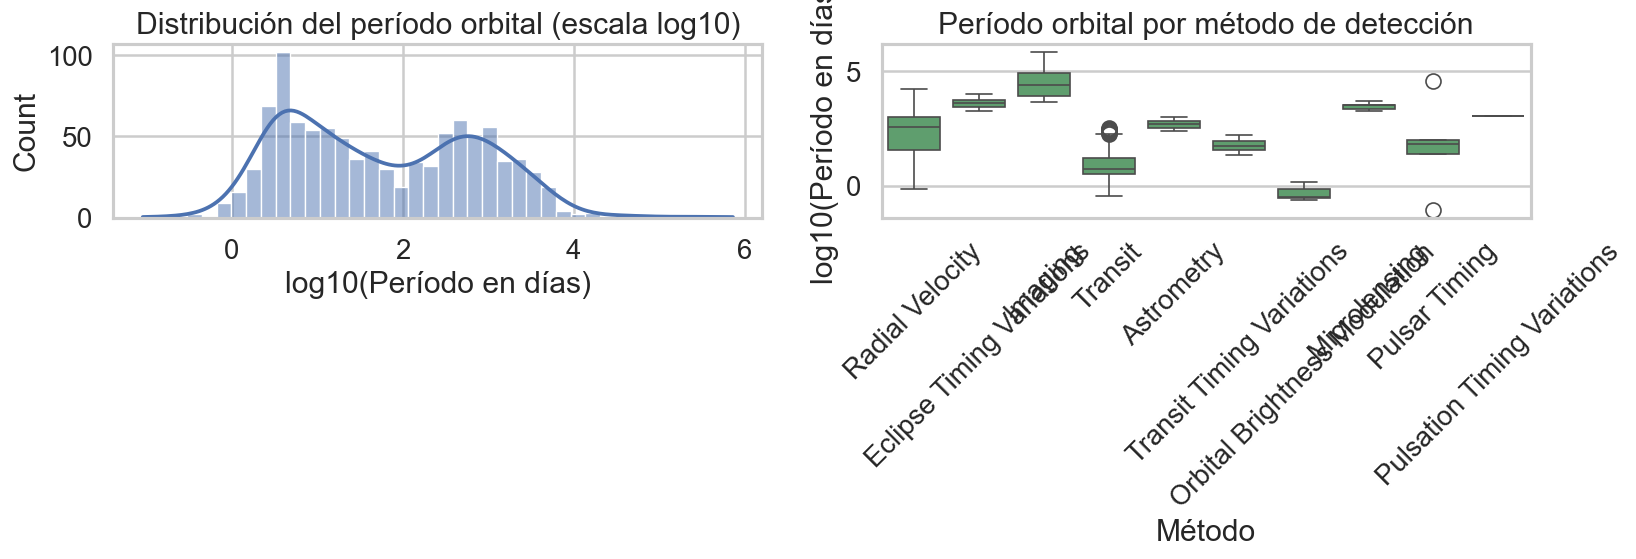

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(planets_clean["log_period"], bins=40, kde=True, ax=ax[0], color="#4C72B0")
ax[0].set_title("Distribución del período orbital (escala log10)")
ax[0].set_xlabel("log10(Período en días)")

sns.boxplot(data=planets_clean, x="method", y="log_period", ax=ax[1], color="#55A868")
ax[1].set_title("Período orbital por método de detección")
ax[1].set_xlabel("Método")
ax[1].set_ylabel("log10(Período en días)")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()


## 7. Funciones auxiliares de remuestreo

Implementaremos funciones generales para bootstrap y Jackknife. Mantendremos el código explícito para facilitar su uso en futuras clases o ejercicios.



In [5]:
def bootstrap_stat(data, stat_func, n_boot=5000, rng=None):
    """Genera estimaciones bootstrap de un estadístico.

    Parámetros:
        data: arreglo 1D con la muestra original.
        stat_func: función que calcula el estadístico.
        n_boot: número de réplicas bootstrap.
        rng: generador aleatorio (numpy).

    Retorna:
        np.ndarray con los estadísticos bootstrap.
"""
    data = np.asarray(data)
    n = data.size
    rng = rng or np.random.default_rng()
    indices = rng.integers(0, n, size=(n_boot, n))
    samples = data[indices]
    return np.apply_along_axis(stat_func, 1, samples)


def jackknife_stats(data, stat_func):
    """Calcula estimaciones Jackknife leave-one-out.

    Parámetros:
        data: arreglo 1D con la muestra original.
        stat_func: función que calcula el estadístico.

    Retorna:
        dict con llaves:
        - "theta_hat": estimación original.
        - "estimates": estimaciones leave-one-out.
        - "mean_jack": promedio leave-one-out.
        - "bias": sesgo Jackknife.
        - "se": error estándar.
        - "pseudo": pseudovalores.
"""
    data = np.asarray(data)
    n = data.size
    estimates = np.array([stat_func(np.delete(data, i)) for i in range(n)])
    theta_hat = stat_func(data)
    mean_jack = estimates.mean()
    bias = (n - 1) * (mean_jack - theta_hat)
    se = np.sqrt((n - 1) / n * np.sum((estimates - mean_jack) ** 2))
    pseudo = n * theta_hat - (n - 1) * estimates
    return {
        "theta_hat": theta_hat,
        "estimates": estimates,
        "mean_jack": mean_jack,
        "bias": bias,
        "se": se,
        "pseudo": pseudo,
    }


def percentile_ci(boot_stats, alpha=0.05):
    """Intervalo percentil a partir de la distribución bootstrap.

    Parámetros:
        boot_stats: arreglo con estimaciones bootstrap.
        alpha: nivel de significancia (0.05 para 95%).

    Retorna:
        np.ndarray de forma (2,) con límites [inferior, superior].
"""
    return np.quantile(boot_stats, [alpha / 2, 1 - alpha / 2])


def basic_ci(theta_hat, boot_stats, alpha=0.05):
    """Intervalo bootstrap básico (reflexión alrededor de theta_hat).

    Parámetros:
        theta_hat: escalar con la estimación puntual original.
        boot_stats: arreglo con estimaciones bootstrap.
        alpha: nivel de significancia (0.05 para 95%).

    Retorna:
        np.ndarray de forma (2,) con límites [inferior, superior].
"""
    q_low, q_high = np.quantile(boot_stats, [1 - alpha / 2, alpha / 2])
    return np.array([2 * theta_hat - q_low, 2 * theta_hat - q_high])


def bca_ci(data, stat_func, boot_stats, alpha=0.05):
    """Intervalo BCa (Bias-Corrected and accelerated).

    Calcula el factor de sesgo z0 y el factor de aceleración a
    con Jackknife, y ajusta los cuantiles bootstrap. Usa NormalDist
    para la CDF y su inversa.

    Parámetros:
        data: arreglo 1D con la muestra original.
        stat_func: función que calcula el estadístico.
        boot_stats: arreglo con estimaciones bootstrap.
        alpha: nivel de significancia (0.05 para 95%).

    Retorna:
        ci: np.ndarray de forma (2,) con límites [inferior, superior].
        info: dict con llaves "z0" y "a" para diagnóstico.
"""
    data = np.asarray(data)
    n = data.size
    theta_hat = stat_func(data)
    norm = NormalDist()

    z0 = norm.inv_cdf((boot_stats < theta_hat).mean())

    jack = np.array([stat_func(np.delete(data, i)) for i in range(n)])
    jack_mean = jack.mean()
    num = np.sum((jack_mean - jack) ** 3)
    den = 6 * (np.sum((jack_mean - jack) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    z_low = norm.inv_cdf(alpha / 2)
    z_high = norm.inv_cdf(1 - alpha / 2)

    pct_low = norm.cdf(z0 + (z0 + z_low) / (1 - a * (z0 + z_low)))
    pct_high = norm.cdf(z0 + (z0 + z_high) / (1 - a * (z0 + z_high)))

    pct_low = np.clip(pct_low, 0, 1)
    pct_high = np.clip(pct_high, 0, 1)

    return np.quantile(boot_stats, [pct_low, pct_high]), {"z0": z0, "a": a}



## 8. Bootstrap de la media y la mediana del período orbital

Trabajaremos con $\log_{10}(P)$ para reducir la asimetría. Estimaremos media, mediana, sesgo y errores estándar usando bootstrap. Además, construiremos intervalos percentiles y BCa.



In [6]:
log_period = planets_clean["log_period"].to_numpy()

boot_mean = bootstrap_stat(log_period, np.mean, n_boot=8000, rng=rng)
boot_median = bootstrap_stat(log_period, np.median, n_boot=8000, rng=rng)

mean_hat = np.mean(log_period)
median_hat = np.median(log_period)

ci_mean_pct = percentile_ci(boot_mean)
ci_mean_bca, bca_info_mean = bca_ci(log_period, np.mean, boot_mean)

ci_median_pct = percentile_ci(boot_median)
ci_median_bca, bca_info_median = bca_ci(log_period, np.median, boot_median)

(mean_hat, median_hat, ci_mean_pct, ci_median_pct)



(np.float64(1.7622969044189767),
 np.float64(1.6018349006641124),
 array([1.69447267, 1.83371808]),
 array([1.45254946, 1.73357315]))

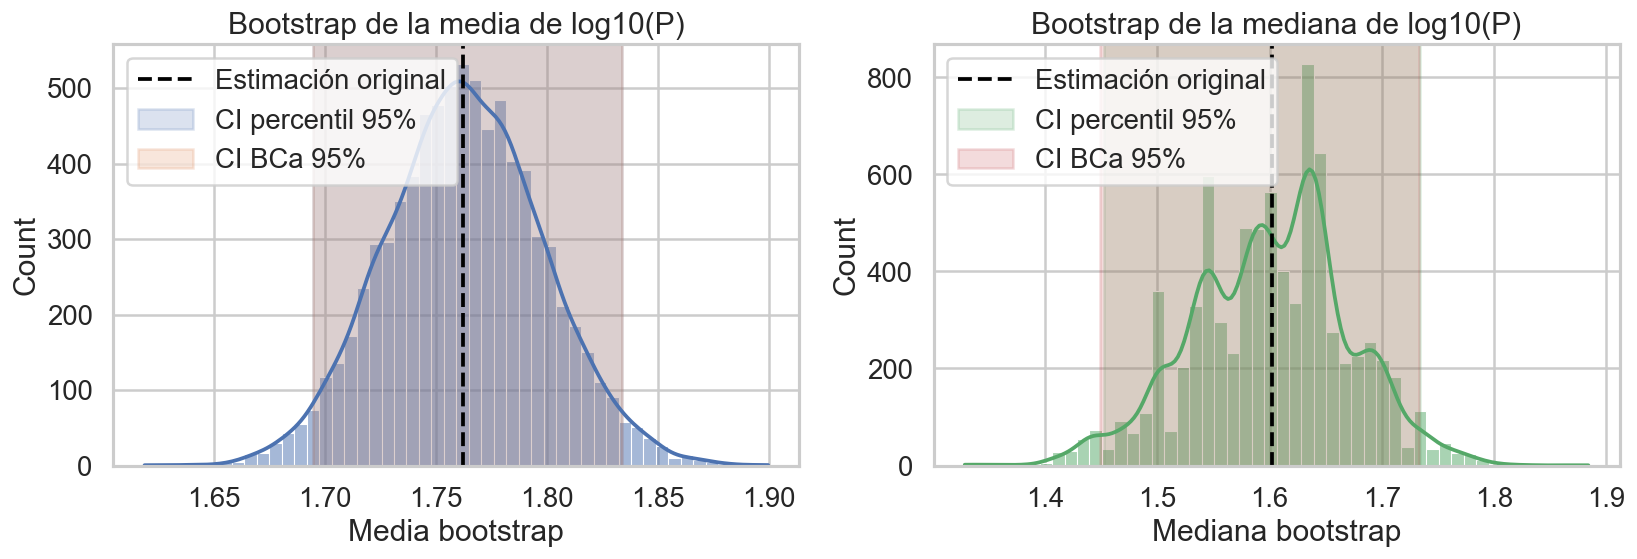

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(boot_mean, bins=50, kde=True, ax=ax[0], color="#4C72B0")
ax[0].axvline(mean_hat, color="black", linestyle="--", label="Estimación original")
ax[0].axvspan(*ci_mean_pct, color="#4C72B0", alpha=0.2, label="CI percentil 95%")
ax[0].axvspan(*ci_mean_bca, color="#DD8452", alpha=0.2, label="CI BCa 95%")
ax[0].set_title("Bootstrap de la media de log10(P)")
ax[0].set_xlabel("Media bootstrap")
ax[0].legend()

sns.histplot(boot_median, bins=50, kde=True, ax=ax[1], color="#55A868")
ax[1].axvline(median_hat, color="black", linestyle="--", label="Estimación original")
ax[1].axvspan(*ci_median_pct, color="#55A868", alpha=0.2, label="CI percentil 95%")
ax[1].axvspan(*ci_median_bca, color="#C44E52", alpha=0.2, label="CI BCa 95%")
ax[1].set_title("Bootstrap de la mediana de log10(P)")
ax[1].set_xlabel("Mediana bootstrap")
ax[1].legend()

plt.tight_layout()



**Interpretación rápida**
- El bootstrap revela la asimetría en la distribución de la mediana, por eso el intervalo BCa puede diferir del percentil.
- La media es más sensible a colas largas; el bootstrap ayuda a cuantificar esa sensibilidad.



## 9. Jackknife para la mediana: sesgo, varianza e influencia

Calcularemos los estimadores leave‑one‑out y los pseudovalores para diagnosticar observaciones influyentes. Esto es útil en astronomía para identificar objetos con períodos extremos.



In [8]:
jack_median = jackknife_stats(log_period, np.median)

jack_median["theta_hat"], jack_median["bias"], jack_median["se"]



(np.float64(1.6018349006641124),
 np.float64(-2.2004620348070603e-13),
 np.float64(0.045994690729532585))

/var/folders/z6/zjckxs610zvcbcvlmd1zqkhh0000gn/T/ipykernel_2355/2292917820.py:12: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


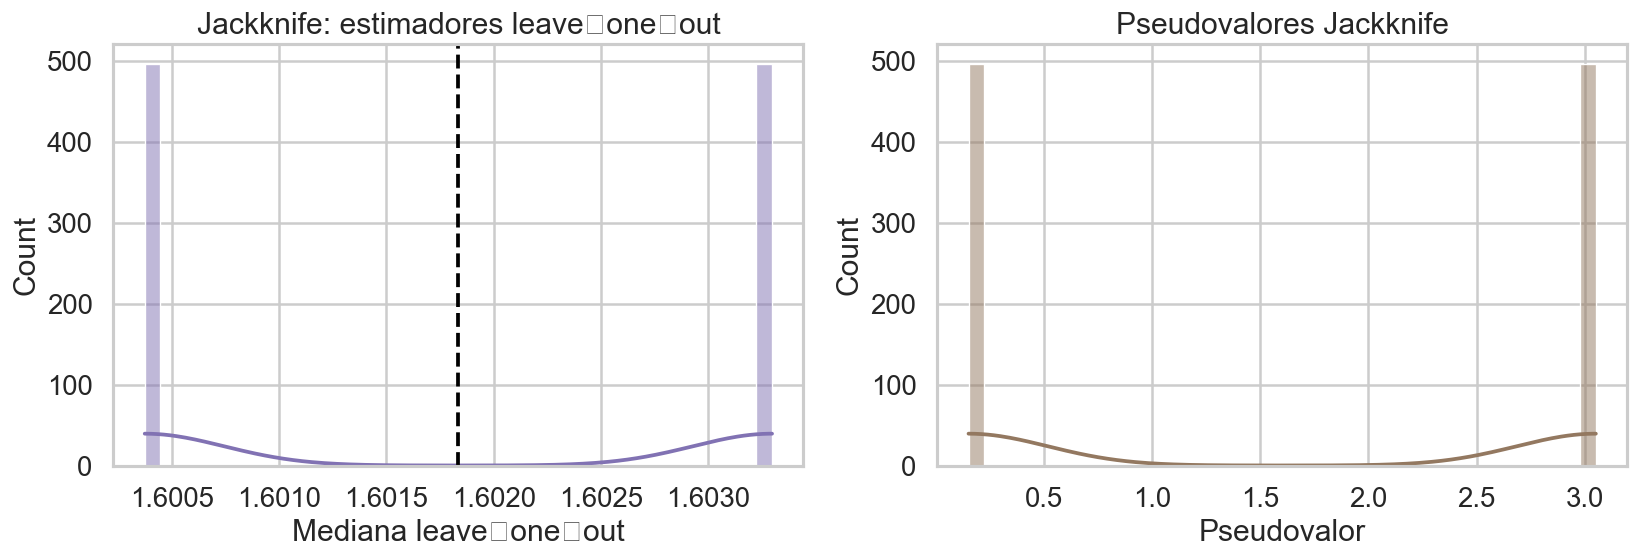

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(jack_median["estimates"], bins=40, kde=True, ax=ax[0], color="#8172B3")
ax[0].axvline(jack_median["theta_hat"], color="black", linestyle="--")
ax[0].set_title("Jackknife: estimadores leave‑one‑out")
ax[0].set_xlabel("Mediana leave‑one‑out")

sns.histplot(jack_median["pseudo"], bins=40, kde=True, ax=ax[1], color="#937860")
ax[1].set_title("Pseudovalores Jackknife")
ax[1].set_xlabel("Pseudovalor")

plt.tight_layout()



## 10. Comparación entre métodos: diferencia de medianas con bootstrap

Compararemos la mediana de $\log_{10}(P)$ entre **Radial Velocity** y **Transit**. Usaremos un bootstrap estratificado (remuestreo dentro de cada grupo) para la diferencia de medianas.



In [10]:
rv_period = planets_clean.loc[planets_clean["method"] == "Radial Velocity", "log_period"].to_numpy()
tr_period = planets_clean.loc[planets_clean["method"] == "Transit", "log_period"].to_numpy()

obs_diff = np.median(rv_period) - np.median(tr_period)

n_boot = 8000
idx_rv = rng.integers(0, rv_period.size, size=(n_boot, rv_period.size))
idx_tr = rng.integers(0, tr_period.size, size=(n_boot, tr_period.size))

boot_diff = np.median(rv_period[idx_rv], axis=1) - np.median(tr_period[idx_tr], axis=1)
ci_diff = percentile_ci(boot_diff)

obs_diff, ci_diff



(np.float64(1.7995326412413593), array([1.68144248, 1.90929639]))

/var/folders/z6/zjckxs610zvcbcvlmd1zqkhh0000gn/T/ipykernel_2355/3409735322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=planets_clean, x="method", y="log_period", ax=ax[0], inner="quartile", palette="Set2")


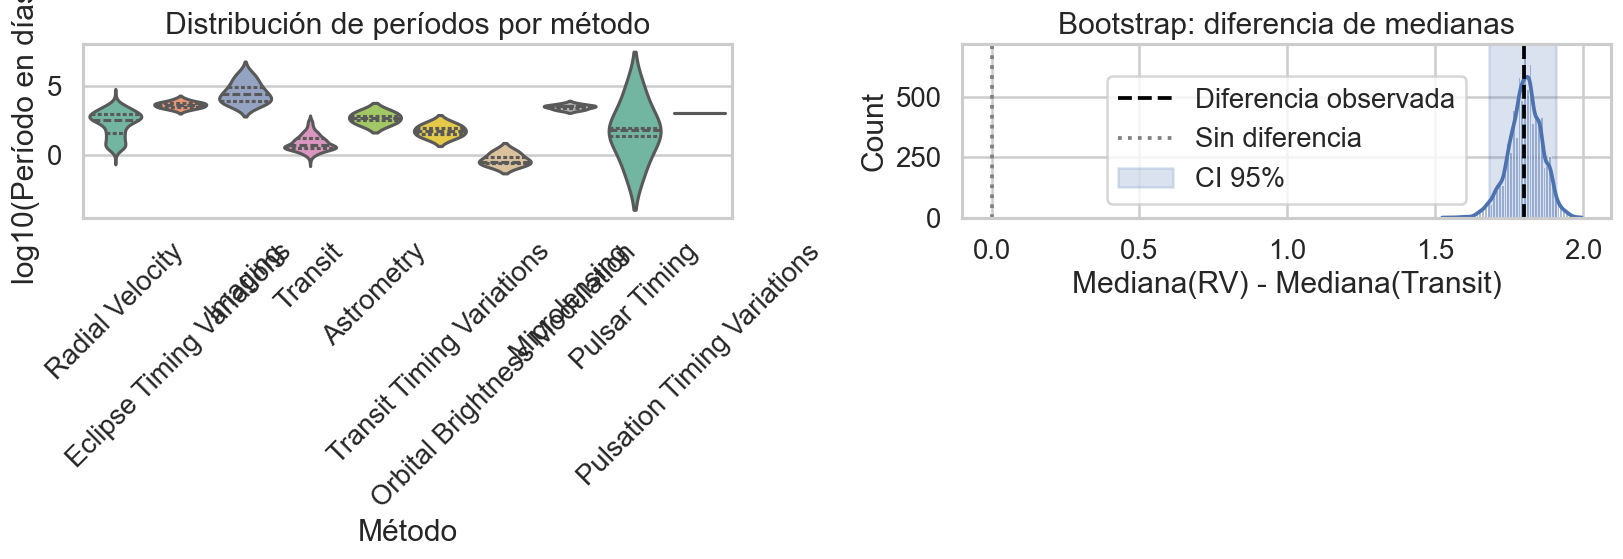

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=planets_clean, x="method", y="log_period", ax=ax[0], inner="quartile", palette="Set2")
ax[0].set_title("Distribución de períodos por método")
ax[0].set_xlabel("Método")
ax[0].set_ylabel("log10(Período en días)")
ax[0].tick_params(axis="x", rotation=45)

sns.histplot(boot_diff, bins=50, kde=True, ax=ax[1], color="#4C72B0")
ax[1].axvline(obs_diff, color="black", linestyle="--", label="Diferencia observada")
ax[1].axvline(0, color="gray", linestyle=":", label="Sin diferencia")
ax[1].axvspan(*ci_diff, color="#4C72B0", alpha=0.2, label="CI 95%")
ax[1].set_title("Bootstrap: diferencia de medianas")
ax[1].set_xlabel("Mediana(RV) - Mediana(Transit)")
ax[1].legend()

plt.tight_layout()



## 11. Bootstrap en regresión: relación masa–período

Analizaremos la relación entre la masa (en $M_J$) y el período orbital en escala logarítmica. Usaremos bootstrap para obtener la incertidumbre de la pendiente y un intervalo de confianza para la curva de regresión.



In [12]:
log_period_mass = planets_mass["log_period"].to_numpy()
log_mass = planets_mass["log_mass"].to_numpy()

slope_hat, intercept_hat = np.polyfit(log_period_mass, log_mass, 1)

n_boot = 4000
indices = rng.integers(0, log_period_mass.size, size=(n_boot, log_period_mass.size))
slopes = np.empty(n_boot)
intercepts = np.empty(n_boot)

for i, idx in enumerate(indices):
    slope_i, intercept_i = np.polyfit(log_period_mass[idx], log_mass[idx], 1)
    slopes[i] = slope_i
    intercepts[i] = intercept_i

ci_slope = percentile_ci(slopes)

x_grid = np.linspace(log_period_mass.min(), log_period_mass.max(), 200)
boot_lines = intercepts[:, None] + slopes[:, None] * x_grid
band_low, band_high = np.quantile(boot_lines, [0.025, 0.975], axis=0)

(slope_hat, ci_slope)



(np.float64(0.5453924425777132), array([0.47198185, 0.6197699 ]))

/var/folders/z6/zjckxs610zvcbcvlmd1zqkhh0000gn/T/ipykernel_2355/3610367454.py:18: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


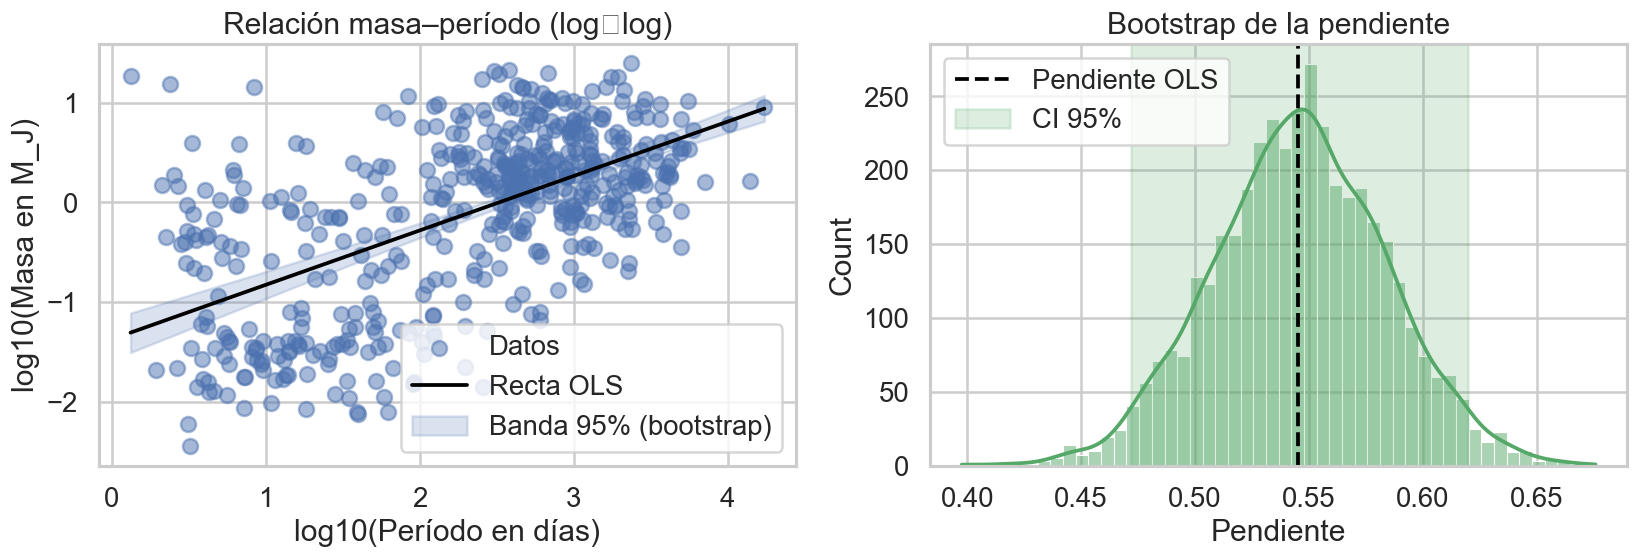

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(log_period_mass, log_mass, alpha=0.5, color="#4C72B0", label="Datos")
ax[0].plot(x_grid, intercept_hat + slope_hat * x_grid, color="black", label="Recta OLS")
ax[0].fill_between(x_grid, band_low, band_high, color="#4C72B0", alpha=0.2, label="Banda 95% (bootstrap)")
ax[0].set_title("Relación masa–período (log‑log)")
ax[0].set_xlabel("log10(Período en días)")
ax[0].set_ylabel("log10(Masa en M_J)")
ax[0].legend()

sns.histplot(slopes, bins=50, kde=True, ax=ax[1], color="#55A868")
ax[1].axvline(slope_hat, color="black", linestyle="--", label="Pendiente OLS")
ax[1].axvspan(*ci_slope, color="#55A868", alpha=0.2, label="CI 95%")
ax[1].set_title("Bootstrap de la pendiente")
ax[1].set_xlabel("Pendiente")
ax[1].legend()

plt.tight_layout()



## 12. Recomendaciones finales

1. **Usar transformaciones logarítmicas** cuando las variables tienen colas largas.
2. **Comparar intervalos percentiles y BCa** para detectar sesgos o asimetrías.
3. **Bootstrap estratificado** cuando se comparan subpoblaciones (p. ej. métodos de detección).
4. **Jackknife como diagnóstico** para identificar observaciones influyentes.
5. **Reportar incertidumbre** siempre que se presenten estimaciones puntuales en estudios astronómicos.

Estos métodos permiten cuantificar la variabilidad de manera flexible, sin suposiciones paramétricas rígidas y con interpretaciones claras.

